In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import math
from imblearn.over_sampling import SMOTE
import graphviz 
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split 

In [2]:
csv = pd.read_csv('Bank Customer Churn Prediction.csv')

In [3]:
df = pd.DataFrame(csv)
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


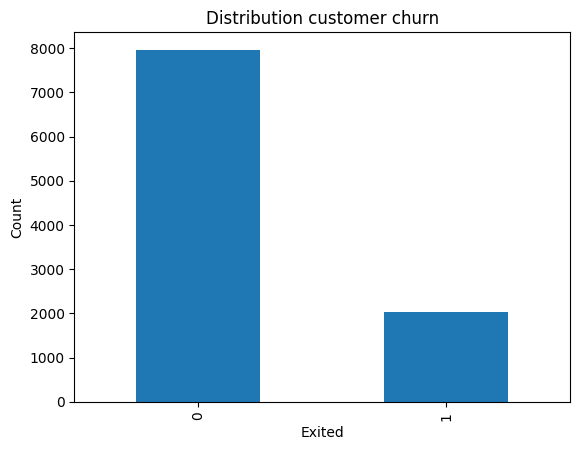

In [5]:
df['churn'].value_counts().plot(kind='bar')
plt.title('Distribution customer churn')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

In [6]:
average_tenure_churned = df.loc[df['churn'] == 1, 'tenure'].mean()
average_tenure_churned.astype('int64')

average_tenure_remain = df.loc[df['churn'] == 0, 'tenure'].mean()

average_tenure_remain.astype('int64'), average_tenure_churned.astype('int64')


(np.int64(5), np.int64(4))

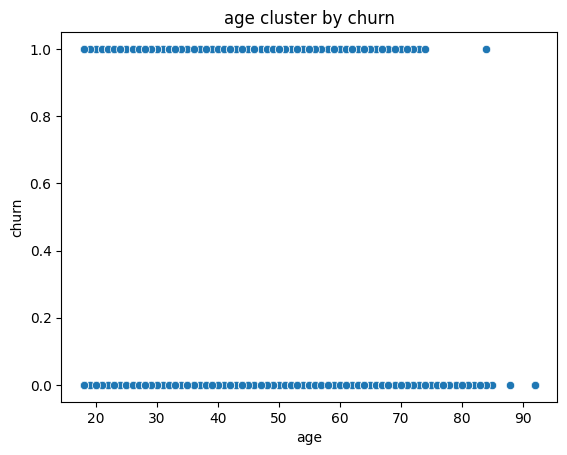

In [7]:
sns.scatterplot(x='age', y='churn', data=df)
plt.title("age cluster by churn")
plt.show()

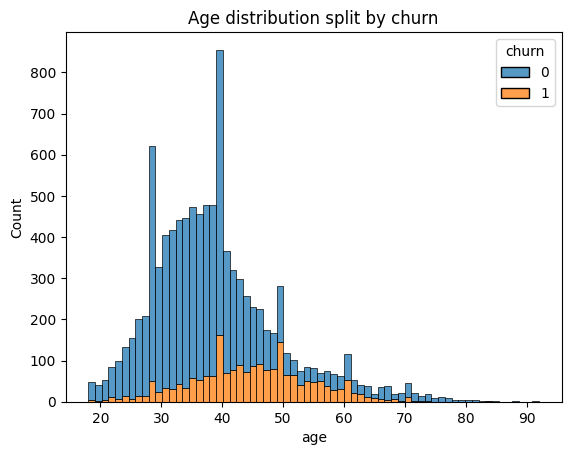

In [8]:
sns.histplot(data=df, x='age', hue='churn', multiple='stack')
plt.title("Age distribution split by churn")
plt.show()


In [9]:
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})

df['country'] = df['country'].replace({'France': 1, 'Germany': 0, 'Spain': 2})

average_age = df.loc[df['churn'] == 1, 'age'].mean()
average_gender = df.loc[df['churn'] == 1, 'gender'].mean()
average_country = df.loc[df['churn'] == 1, 'country'].mean()

#45yr old Male France 
print(f'Most vulnerible demographic by average is: {math.ceil(average_age)}, {math.ceil(average_gender)}, {math.ceil(average_country)}')

Most vulnerible demographic by average is: 45, 1, 1


In [10]:
df['country'].unique()

array([1, 2, 0], dtype=object)

In [11]:
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,1,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,1,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,1,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,2,1,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,1,1,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,0,0,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,1,1,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,1,1,27,2,134603.88,1,1,1,71725.73,0


In [12]:
df_new = df.drop('customer_id', axis=1)
df_new

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,1,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,1,0,42,8,159660.80,3,1,0,113931.57,1
3,699,1,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,1,39,5,0.00,2,1,0,96270.64,0
9996,516,1,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,1,0,36,7,0.00,1,0,1,42085.58,1
9998,772,0,1,42,3,75075.31,2,1,0,92888.52,1


NORMALIZED BALANCE AND ESTIMATED_SALARY

In [13]:
scaler = MinMaxScaler()

columns = ['balance', 'estimated_salary']
df_new[columns] = scaler.fit_transform(df_new[columns])

object_fix = ['gender', 'country']

df[object_fix] = df[object_fix].astype('category') 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customer_id       10000 non-null  int64   
 1   credit_score      10000 non-null  int64   
 2   country           10000 non-null  category
 3   gender            10000 non-null  category
 4   age               10000 non-null  int64   
 5   tenure            10000 non-null  int64   
 6   balance           10000 non-null  float64 
 7   products_number   10000 non-null  int64   
 8   credit_card       10000 non-null  int64   
 9   active_member     10000 non-null  int64   
 10  estimated_salary  10000 non-null  float64 
 11  churn             10000 non-null  int64   
dtypes: category(2), float64(2), int64(8)
memory usage: 800.9 KB


In [14]:
#there is a imbalance in churn, I will be using SMOTE to solve this issue. 

X = df_new.drop('churn', axis=1)
y = df_new['churn']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [16]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

churn
0    5972
1    1528
Name: count, dtype: int64
churn
1    5972
0    5972
Name: count, dtype: int64


In [17]:
object_column = ['gender', 'country']

X_train_smote[object_column] = X_train_smote[object_column].astype('category')
X_test[object_column] = X_test[object_column].astype('category')

# X_test.info()
X_train_smote.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,735,1.0,0.0,53,8,0.493608,2,0,1,0.852298
1,518,1.0,1.0,38,3,0.362529,1,0,1,0.811543
2,572,0.0,0.0,54,9,0.388136,1,1,1,0.978895
3,619,1.0,0.0,35,4,0.360358,1,1,1,0.102728
4,608,2.0,0.0,41,1,0.334031,1,0,1,0.562709


In [18]:
X_train_smote['gender'] = X_train_smote['gender'].astype('int64')
X_train_smote['country']= X_train_smote['country'].astype('int64')

X_test['gender'] = X_test['gender'].astype('int64')
X_test['country']= X_test['country'].astype('int64')

In [19]:
#converting data to DMatrix, helps improve training speed and is more memory efficient.
xgb_train = xgb.DMatrix(X_train_smote, y_train_smote)
xgb_test = xgb.DMatrix(X_test, y_test)

MODEL CREATION, TRAINING AND EVALUATION 

In [20]:
params = {
    'objective': 'binary:logistic', 
    'eval_metric': ['logloss', 'auc', 'rmse'],
    'max_depth': 5, 
    'learning_rate': 0.2, 
}

evals_result = {}
n = 127

model = xgb.train(
    params=params, 
    dtrain=xgb_train, 
    num_boost_round=n, 
    evals=[(xgb_train, 'train'), (xgb_test, 'test')], 
    evals_result=evals_result, 
    verbose_eval=True 
)

epochs = len(evals_result['train']['logloss'])
x_axis = range(0, epochs)

[0]	train-logloss:0.61244	train-auc:0.88265	train-rmse:0.45823	test-logloss:0.62115	test-auc:0.81771	test-rmse:0.46289
[1]	train-logloss:0.55734	train-auc:0.89635	train-rmse:0.42870	test-logloss:0.57437	test-auc:0.83171	test-rmse:0.43816
[2]	train-logloss:0.51439	train-auc:0.90244	train-rmse:0.40560	test-logloss:0.53590	test-auc:0.84277	test-rmse:0.41788
[3]	train-logloss:0.48274	train-auc:0.90757	train-rmse:0.38901	test-logloss:0.50800	test-auc:0.84947	test-rmse:0.40359
[4]	train-logloss:0.45880	train-auc:0.91065	train-rmse:0.37681	test-logloss:0.48868	test-auc:0.85232	test-rmse:0.39406
[5]	train-logloss:0.44008	train-auc:0.91199	train-rmse:0.36786	test-logloss:0.47325	test-auc:0.85196	test-rmse:0.38707
[6]	train-logloss:0.42468	train-auc:0.91398	train-rmse:0.36065	test-logloss:0.45892	test-auc:0.85479	test-rmse:0.38028
[7]	train-logloss:0.41156	train-auc:0.91653	train-rmse:0.35469	test-logloss:0.44863	test-auc:0.85615	test-rmse:0.37610
[8]	train-logloss:0.40153	train-auc:0.91826	trai

In [21]:
preds = model.predict(xgb_test)
preds = np.round(preds)
accuracy = accuracy_score(y_test, preds)
classification = classification_report(y_test, preds)

# print('Accuracy of the xgBoost model: ', accuracy*100)
print(classification)
print('*****************************************************')
print('Accuracy of the xgBoost model: ', accuracy*100)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1991
           1       0.56      0.64      0.60       509

    accuracy                           0.82      2500
   macro avg       0.73      0.76      0.74      2500
weighted avg       0.83      0.82      0.83      2500

*****************************************************
Accuracy of the xgBoost model:  82.32000000000001


In [22]:
#Feature Importance 
importance = model.get_score(importance_type='gain')
key_array = importance.keys()

value_array = [math.ceil(value) for value in importance.values()]

feature_importance = dict(zip(key_array, value_array))
# feature_importance = np.asarray(feature_importance)
feature_importance

{'credit_score': 4,
 'country': 19,
 'gender': 33,
 'age': 15,
 'tenure': 4,
 'balance': 10,
 'products_number': 23,
 'credit_card': 9,
 'active_member': 73,
 'estimated_salary': 4}

([<matplotlib.patches.Wedge at 0x27083c0b380>,
 [Text(1.097693108645632, 0.07120280353952863, 'credit_score'),
  Text(0.996519935348527, 0.4657767903759995, 'country'),
  Text(0.3161155605013322, 1.0535990472703214, 'gender'),
  Text(-0.5136204861352686, 0.9727250362883494, 'age'),
  Text(-0.7840898343823215, 0.7714940904623339, 'tenure'),
  Text(-0.9374385758074618, 0.5755075295667971, 'balance'),
  Text(-1.0998557719833528, 0.0178123786986227, 'products_number'),
  Text(-0.9642805227096157, -0.5293043297790699, 'credit_card'),
  Text(0.28183173709884973, -1.0632830629535321, 'active_member'),
  Text(1.097693095631001, -0.07120300417840801, 'estimated_salary')])

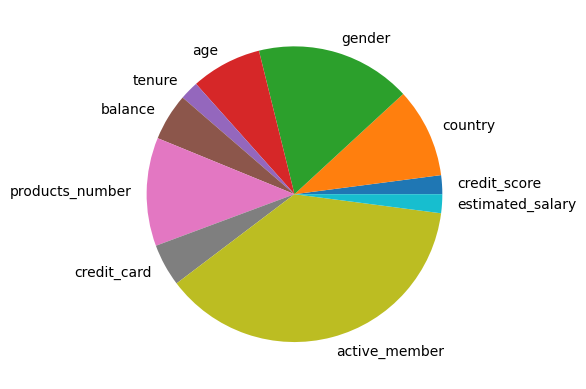

In [23]:
#plotting feature importance 

plt.pie(feature_importance.values(), labels=feature_importance.keys())

Text(0.5, 1.0, 'XGBoost AUC')

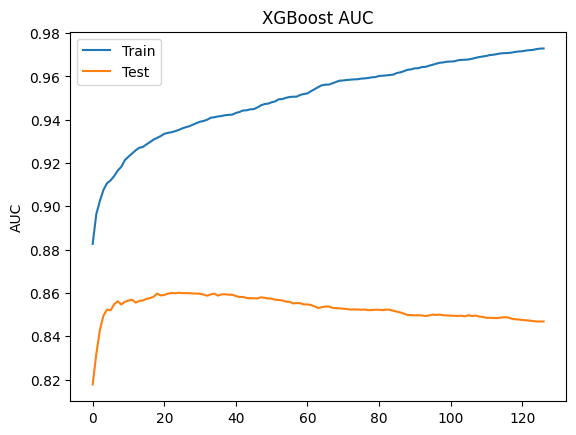

In [24]:
plt.plot(x_axis, evals_result['train']['auc'], label='Train')
plt.plot(x_axis, evals_result['test']['auc'], label='Test')
plt.legend()
plt.ylabel('AUC')
plt.title('XGBoost AUC')

Text(0.5, 1.0, 'XGBoost RMSE')

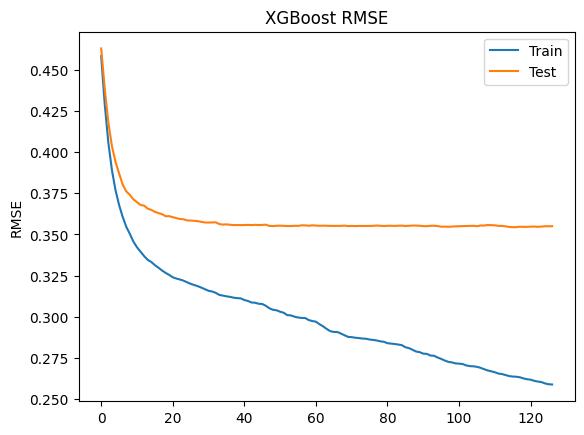

In [25]:
#We can see the models performance after ≈35 trees starts to decrease. 
plt.plot(x_axis, evals_result['train']['rmse'], label='Train')
plt.plot(x_axis, evals_result['test']['rmse'], label='Test')
plt.legend()
plt.ylabel('RMSE')
plt.title('XGBoost RMSE')

Text(0.5, 1.0, 'XGBoost Logloss')

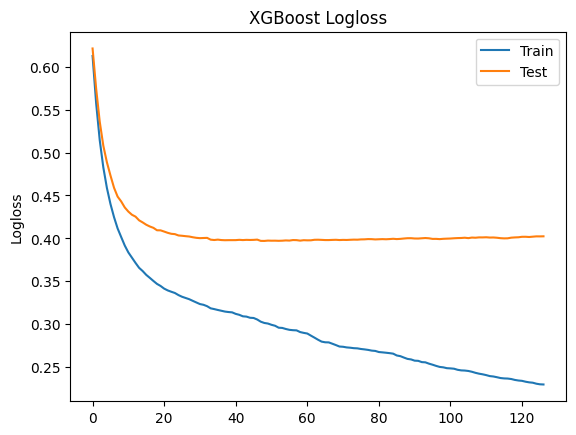

In [26]:
plt.plot(x_axis, evals_result['train']['logloss'], label='Train')
plt.plot(x_axis, evals_result['test']['logloss'], label='Test')
plt.legend()
plt.ylabel('Logloss')
plt.title('XGBoost Logloss')

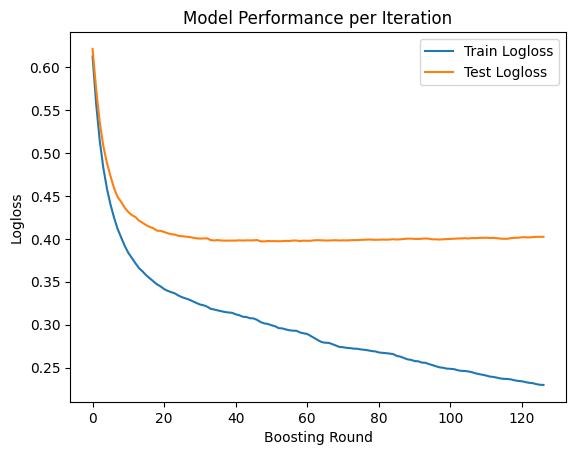

In [27]:
#The models performance starts to plateu after 20 trees
plt.plot(evals_result['train']['logloss'], label='Train Logloss')
plt.plot(evals_result['test']['logloss'], label='Test Logloss')
plt.xlabel("Boosting Round")
plt.ylabel("Logloss")
plt.title("Model Performance per Iteration")
plt.legend()
plt.show()

In [28]:
# model.feature_names
df_new.columns
model.feature_names

['credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

In [29]:
data = [500, 1, 1, 23, 4, 0.65500, 1, 0, 1, 0.25565]

transformed_data = np.asarray(data).reshape(1, -1)

array = xgb.DMatrix(transformed_data, feature_names=model.feature_names)
test_pred = model.predict(array)
test_pred.dtype

dtype('float32')

In [30]:
df_new

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,1,0,42,2,0.000000,1,1,1,0.506735,1
1,608,2,0,41,1,0.334031,1,0,1,0.562709,0
2,502,1,0,42,8,0.636357,3,1,0,0.569654,1
3,699,1,0,39,1,0.000000,2,0,0,0.469120,0
4,850,2,0,43,2,0.500246,1,1,1,0.395400,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,1,39,5,0.000000,2,1,0,0.481341,0
9996,516,1,1,35,10,0.228657,1,1,1,0.508490,0
9997,709,1,0,36,7,0.000000,1,0,1,0.210390,1
9998,772,0,1,42,3,0.299226,2,1,0,0.464429,1


In [ ]:
df_new['churn_probability(%)'] = "" 

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,churn_probability(%)
0,619,1,0,42,2,0.000000,1,1,1,0.506735,1,
1,608,2,0,41,1,0.334031,1,0,1,0.562709,0,
2,502,1,0,42,8,0.636357,3,1,0,0.569654,1,
3,699,1,0,39,1,0.000000,2,0,0,0.469120,0,
4,850,2,0,43,2,0.500246,1,1,1,0.395400,0,


In [130]:
df_new['country'] = pd.to_numeric(df_new['country'])
df_new['gender'] = pd.to_numeric(df_new['gender'])
new_df = df_new.drop(columns=['churn_probability(%)'])

row_array = new_df.iloc[0].tolist()
final_array = np.asarray(row_array).reshape(1, -1).astype('int64')
final_array = np.delete(final_array, 10).reshape(1, -1)
final_array = xgb.DMatrix(final_array, feature_names=model.feature_names)

In [145]:
new_df['country'] = pd.to_numeric(new_df['country'])
new_df['gender'] = pd.to_numeric(new_df['gender'])
new_df['churn_probability(%)'] = 0
new_df['churn_probability(%)'] = new_df['churn_probability(%)'].astype('int64')
# new_df.info()
rows = len(new_df)

final_array

for x in range(0, rows):
    row_array = new_df.iloc[x].tolist()
    final_array = np.asarray(row_array).reshape(1, -1).astype('float64').astype('int64')
    final_array = np.delete(final_array, 9).reshape(1, -1)
    final_array = xgb.DMatrix(final_array, feature_names=model.feature_names)
    new_df['churn_probability(%)'] = model.predict(final_array)

ValueError: ('feature names must have the same length as the number of data columns, ', 'expected 11, got 10')

In [151]:
pred_features = new_df[model.feature_names].astype('float64').astype('int64')
all_rows_dmatrix = xgb.DMatrix(pred_features, feature_names=model.feature_names)
new_df['churn_probability(%)'] = model.predict(all_rows_dmatrix)

new_df['churn_probability(%)'] = new_df['churn_probability(%)']*100
new_df.head(5)

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,churn_probability(%)
0,619,1,0,42,2,0.000000,1,1,1,0.506735,1,27.715645
1,608,2,0,41,1,0.334031,1,0,1,0.562709,0,48.779202
2,502,1,0,42,8,0.636357,3,1,0,0.569654,1,62.318523
3,699,1,0,39,1,0.000000,2,0,0,0.469120,0,2.773768
4,850,2,0,43,2,0.500246,1,1,1,0.395400,0,38.980370
